# Notebook 09 — SABR / SSVI Model Calibration and Comparison

Calibrates the SABR and SSVI models to the implied volatility surface.
SSVI is guaranteed to be arbitrage-free under Gatheral-Jacquier parametric constraints,
whereas SABR Hagan approximation can exhibit calendar/butterfly arbitrage at extreme strikes.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from pricing.sabr import sabr_iv_surface, ssvi_iv_surface
from fno_model import MirrorPaddedFNO2d
from calibrate_fast import calibrate_sabr, calibrate_ssvi


Device: cuda


## 1. Load FNO surrogates

In [2]:
model_sabr = MirrorPaddedFNO2d(param_dim=3).to(DEVICE)
model_sabr.load_state_dict(torch.load("../artifacts/weights/fno_sabr_final_prod.pth", map_location=DEVICE))
model_sabr.eval()

model_ssvi = MirrorPaddedFNO2d(param_dim=11).to(DEVICE)
model_ssvi.load_state_dict(torch.load("../artifacts/weights/fno_ssvi_final_prod.pth", map_location=DEVICE))
model_ssvi.eval()
print("SABR & SSVI FNO models loaded.")


SABR & SSVI FNO models loaded.


## 2. Generate a Target Implied Volatility Surface

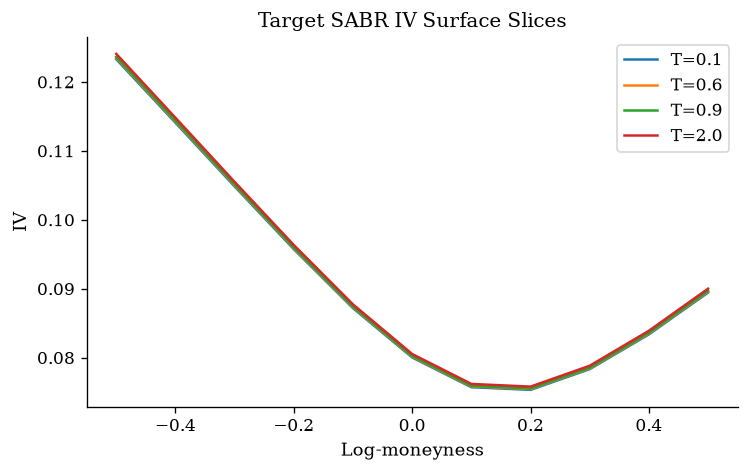

In [3]:
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

# True SABR parameters
alpha_t = 0.08
rho_t = -0.4
nu_t = 0.3

# Target SABR surface
iv_target = sabr_iv_surface(
    F=1.0, T_grid=T_GRID, k_grid=K_GRID,
    alpha=alpha_t, beta=1.0, rho=rho_t, nu=nu_t,
    iv_type="lognormal"
)

# Plot target surface
plt.figure(figsize=(7, 4))
for i, T in enumerate([0.1, 0.5, 1.0, 2.0]):
    idx = np.abs(T_GRID - T).argmin()
    plt.plot(K_GRID, iv_target[idx], label=f"T={T_GRID[idx]:.1f}")
plt.title("Target SABR IV Surface Slices")
plt.xlabel("Log-moneyness")
plt.ylabel("IV")
plt.legend()
plt.show()


## 3. Fast Gauss-Newton Calibration

In [4]:
# Calibrate SABR
res_sabr = calibrate_sabr(model_sabr, iv_target, T_GRID, K_GRID, max_iter=20)
print("SABR Calibrated Params:")
print(f"  alpha = {res_sabr['alpha']:.4f} (true={alpha_t})")
print(f"  rho   = {res_sabr['rho']:.4f} (true={rho_t})")
print(f"  nu    = {res_sabr['nu']:.4f} (true={nu_t})")
print(f"  MSE   = {res_sabr['final_mse']:.2e}")

# Calibrate SSVI
theta_atm_init = iv_target[:, 5] ** 2 * T_GRID
res_ssvi = calibrate_ssvi(model_ssvi, iv_target, T_GRID, K_GRID, theta_atm_init=theta_atm_init, max_iter=20)
print("\nSSVI Calibrated Params:")
print(f"  rho   = {res_ssvi['rho']:.4f}")
print(f"  eta   = {res_ssvi['eta']:.4f}")
print(f"  gamma = {res_ssvi['gamma']:.4f}")
print(f"  MSE   = {res_ssvi['final_mse']:.2e}")


SABR Calibrated Params:
  alpha = 0.0785 (true=0.08)
  rho   = -0.4726 (true=-0.4)
  nu    = 0.2933 (true=0.3)
  MSE   = 1.34e-06



SSVI Calibrated Params:
  rho   = -0.8708
  eta   = 0.0500
  gamma = 0.5000
  MSE   = 9.36e-04
